# XGBoost — Unified Core Model Training v2

Updated XGBoost model that now accepts `text` through use of TF-IDF

| Input | Required |
|---|---|
| `text` | Optional |
| `url` | Optional |
| `timestamp` | Yes |
| `hazard_type` | Yes |
| `hazard_severity` | Yes |
| `hazard_timestamp` | Yes |
| `hazard_location` | Yes |
| `hazard_status` | Yes |
| `alert_level` | No |
| `source` | Yes |

added features:
- imported scipy for combining matrices
- imported string and re for text cleaning
- imported TfidfVectorizer
- Numeric Feature definition added
- text cleaning function in preprocessing to normalise the text
- moved categorical encoding and force convert for numerical features after train/test split
- added text vectorisation for both the `text` and `url` columns, both requiring different vectorisers
- added joblib.dump for vectorisers
- used hstack to combine text and numeric data (combination order matters)
- added function that maps feature names to columns for analysis with text data.
- added a feature schema and edited the feature importance section to work with the feature column function

config changes:
- removed alert_level

## Prerequisites 

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'scikit-learn', 'joblib', 'pyyaml', 'scipy'], check=True)

CompletedProcess(args=['pip', 'install', 'xgboost', 'scikit-learn', 'joblib', 'pyyaml', 'scipy'], returncode=0)

## 1. Imports & Config

In [2]:
import yaml
import numpy as np
import pandas as pd
import xgboost as xgb
import json
import joblib
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import re
import string
from scipy.sparse import hstack, csr_matrix

CONFIG_PATH = Path('../configs/optimised_xgboost_config_v2.yaml')

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

CHECKPOINT_DIR = Path(config['output']['path'])
REPORT_DIR     = Path(config['output']['reports_path'])
LOG_DIR        = Path(config['output']['log_path'])

for d in [CHECKPOINT_DIR, REPORT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Run ID: {RUN_ID}')
print(f'Config:\n{json.dumps(config, indent=2)}')

Run ID: 20260901_002047
Config:
{
  "dataset": {
    "path": "../../../../datasets/phoenix_combined_dataset_large2.csv",
    "target_column": "hazard_severity",
    "train_split": 0.7,
    "val_split": 0.15,
    "test_split": 0.15,
    "random_seed": 42,
    "stratify": true
  },
  "features": {
    "text_features": [
      "text",
      "url"
    ],
    "context_features": [
      "timestamp",
      "hazard_type",
      "hazard_timestamp",
      "hazard_location",
      "hazard_status",
      "source"
    ],
    "categorical_cols": [
      "hazard_type",
      "hazard_location",
      "hazard_status",
      "source"
    ],
    "datetime_cols": [
      "timestamp",
      "hazard_timestamp"
    ]
  },
  "preprocessing": {
    "missing_value_strategy": "none",
    "normalization": "none",
    "encoding": "onehot",
    "feature_selection": false,
    "selected_features": []
  },
  "model": {
    "type": "sklearn",
    "name": "xgboost",
    "task_type": "classification",
    "hyperparamet

## 2. Feature Definitions

In [3]:
feat_cfg         = config['features']
TEXT_FEATURES    = feat_cfg['text_features']     # ['text', 'url'] — optional
CONTEXT_FEATURES = feat_cfg['context_features']
ALL_FEATURES     = TEXT_FEATURES + CONTEXT_FEATURES
CATEGORICAL_COLS = feat_cfg['categorical_cols']
DATETIME_COLS    = feat_cfg['datetime_cols']
TARGET_COL       = config['dataset']['target_column']
NUMERIC_FEATURES = [c for c in ALL_FEATURES if c not in TEXT_FEATURES] # group all non text features for better processing later


print(f'Total features defined: {len(ALL_FEATURES)}')
print(f'text features: {TEXT_FEATURES}')
print(f'text features: {NUMERIC_FEATURES}')
print(f'Target: {TARGET_COL}')

Total features defined: 8
text features: ['text', 'url']
text features: ['timestamp', 'hazard_type', 'hazard_timestamp', 'hazard_location', 'hazard_status', 'source']
Target: hazard_severity


## 3. Load Data

In [4]:
df = pd.read_csv(config['dataset']['path'])
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (2000, 9)
Columns: ['url', 'text', 'timestamp', 'hazard_type', 'hazard_severity', 'hazard_timestamp', 'hazard_location', 'hazard_status', 'source']


,url,text,timestamp,hazard_type,hazard_severity,hazard_timestamp,hazard_location,hazard_status,source
0,https://twitter.com/status/928374650192,Hoax: Power company secretly rationing electri...,"August 09, 2019",misinformation,low,"August 09, 2019",France,pending,Social Media Disaster Tweets Dataset
1,https://reddit.com/r/conspiracy/abc123,Fabricated: Mayor orders mandatory evacuation ...,"January 03, 2021",misinformation,low,"January 03, 2021","Georgia, USA",resolved,Claim Fraud Detection Dataset
2,https://www.fs.usda.gov/managing-land/fire,NASA FIRMS: Grassland fire sweeping through Mi...,"July 17, 2022",wildfire,medium,"July 18, 2022","Catalonia, Spain",pending,USDA Forest Service
3,https://www.phishtank.com/,Phishing URL targeting government employees vi...,"May 27, 2021",cyber_threat,critical,"May 27, 2021",Nigeria,monitoring,Spamhaus (SBL/XBL/PBL)
4,https://www.noaa.gov/weather,Open-Meteo: Derecho system tracking across Mid...,"October 23, 2017",weather_hazard,critical,"October 23, 2017","Southern Ontario, Canada",pending,WMO


## 4. Preprocessing 1

In [5]:
# ── Ensure all expected columns exist, NaN if absent ──────────────────────
# This is the key step that makes the model robust to missing inputs.
# XGBoost learns the optimal split direction for NaN at training time.
for col in ALL_FEATURES:
    if col not in df.columns:
        df[col] = np.nan
        print(f'  Column "{col}" not in dataset — added as NaN')

# ── Parse datetimes -> unix timestamp (numeric) ───────────────────────────
for col in DATETIME_COLS:
    if df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], errors='coerce').astype('int64') // 10**9

# ── Text features: use TF-IDF ─────────
# takes the text column and strips it to remove capitalisation and punctuation
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

if 'text' in TEXT_FEATURES:
    df['text'] = df['text'].fillna('').apply(clean_text)
if 'url' in TEXT_FEATURES:
    df['url'] = df['url'].fillna('').astype(str).str.lower()




# ── Target encoding ───────────────────────────────────────────────────────
target_le = LabelEncoder()
df[TARGET_COL] = target_le.fit_transform(df[TARGET_COL].astype(str))
print(f'Target classes: {target_le.classes_}')

Target classes: ['critical' 'high' 'low' 'medium']


## 5. Train/Test split

In [6]:

X = df[ALL_FEATURES]  
y = df[TARGET_COL]

cfg_ds   = config['dataset']
seed     = cfg_ds['random_seed']
stratify = y if cfg_ds['stratify'] else None

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=1 - cfg_ds['train_split'],
    random_state=seed,
    stratify=stratify
)

val_ratio = cfg_ds['val_split'] / (cfg_ds['val_split'] + cfg_ds['test_split'])
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1 - val_ratio,
    random_state=seed,
    stratify=y_temp if cfg_ds['stratify'] else None
)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (1399, 8), Val: (300, 8), Test: (301, 8)


## 6. Preprocessing after split

In [7]:
# PREPROCESSING DONE TO X AFTER TRAIN/TEST SPLIT TO PREVENT ISSUES
# ── Encode categoricals ───────────────────────────────────────────────────
label_encoders = {}
for col in CATEGORICAL_COLS:
    X_train[col] = X_train[col].fillna('__missing__').astype(str)
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    label_encoders[col] = le

    for split_df in (X_val, X_test):
        split_df[col] = split_df[col].fillna('__missing__').astype(str)
        # map unseen categories (present in val/test but not train) to a fixed "unknown" bucket
        known = set(le.classes_)
        split_df[col] = split_df[col].apply(lambda x: x if x in known else '__missing__')
        split_df[col] = le.transform(split_df[col])


print('\nMissing value summary after preprocessing (train):')
print(X_train[ALL_FEATURES].isnull().sum())

# TEXT VECTORISATION AFTER TRAIN/TEST SPLIT 
# ── TF-IDF ─────────────────────────
text_vectorizers = {}
train_text_mats, val_text_mats, test_text_mats = [], [], []

if 'text' in TEXT_FEATURES:
    text_vec = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=2,
        max_df=0.9
    )
    train_text_mats.append(text_vec.fit_transform(X_train['text']))
    val_text_mats.append(text_vec.transform(X_val['text']))
    test_text_mats.append(text_vec.transform(X_test['text']))
    text_vectorizers['text'] = text_vec

if 'url' in TEXT_FEATURES:
    url_vec = TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        max_features=5000
    )
    train_text_mats.append(url_vec.fit_transform(X_train['url']))
    val_text_mats.append(url_vec.transform(X_val['url']))
    test_text_mats.append(url_vec.transform(X_test['url']))
    text_vectorizers['url'] = url_vec


# Save vectorisers for inference later
for name, vec in text_vectorizers.items():
    joblib.dump(vec, CHECKPOINT_DIR / f'tfidf_{name}_{RUN_ID}.pkl')
    
# Force convert any possible strings in numeric columns to numeric
for split_df in (X_train, X_val, X_test):
    for col in NUMERIC_FEATURES:
        if split_df[col].dtype == object or split_df[col].dtype.name == 'str':
            split_df[col] = pd.to_numeric(split_df[col], errors='coerce')

print('\nMissing value summary after preprocessing (train):')
print(X_train[NUMERIC_FEATURES].isnull().sum())


Missing value summary after preprocessing (train):


text                0
url                 0
timestamp           0
hazard_type         0
hazard_timestamp    0
hazard_location     0
hazard_status       0
source              0
dtype: int64

Missing value summary after preprocessing (train):
timestamp           1399
hazard_type            0
hazard_timestamp    1399
hazard_location        0
hazard_status          0
source                 0
dtype: int64


## 6.5. Combine Text and Numerical Data

In [8]:
# ── Combine numeric features + TF-IDF sparse matrices into final matrices ─
X_train_final = hstack([csr_matrix(X_train[NUMERIC_FEATURES].values)] + train_text_mats).tocsr()
X_val_final   = hstack([csr_matrix(X_val[NUMERIC_FEATURES].values)] + val_text_mats).tocsr()
X_test_final  = hstack([csr_matrix(X_test[NUMERIC_FEATURES].values)] + test_text_mats).tocsr()

print(f'Final train matrix: {X_train_final.shape}')

Final train matrix: (1399, 7777)


## 7. Train Model

In [9]:
hp = config['model']['hyperparameters']

model = xgb.XGBClassifier(
    n_estimators     = hp['n_estimators'],
    learning_rate    = hp['learning_rate'],
    max_depth        = hp['max_depth'],
    random_state     = hp['random_state'],
    eval_metric      = hp['eval_metric'],
    tree_method      = hp.get('tree_method', 'hist'),
    enable_categorical = False,
    verbosity        = 1 if config['training']['verbose'] else 0,
)

model.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    verbose=config['training']['verbose'],
)

print('Training complete.')

[0]	validation_0-mlogloss:1.37815
[1]	validation_0-mlogloss:1.37155
[2]	validation_0-mlogloss:1.36582
[3]	validation_0-mlogloss:1.36065
[4]	validation_0-mlogloss:1.35548
[5]	validation_0-mlogloss:1.35065
[6]	validation_0-mlogloss:1.34656
[7]	validation_0-mlogloss:1.34218
[8]	validation_0-mlogloss:1.33887
[9]	validation_0-mlogloss:1.33408
[10]	validation_0-mlogloss:1.33040
[11]	validation_0-mlogloss:1.32788
[12]	validation_0-mlogloss:1.32491
[13]	validation_0-mlogloss:1.32275
[14]	validation_0-mlogloss:1.32012
[15]	validation_0-mlogloss:1.31765
[16]	validation_0-mlogloss:1.31432
[17]	validation_0-mlogloss:1.31210
[18]	validation_0-mlogloss:1.31019
[19]	validation_0-mlogloss:1.30855
[20]	validation_0-mlogloss:1.30760
[21]	validation_0-mlogloss:1.30546
[22]	validation_0-mlogloss:1.30357
[23]	validation_0-mlogloss:1.30178
[24]	validation_0-mlogloss:1.29991
[25]	validation_0-mlogloss:1.29854
[26]	validation_0-mlogloss:1.29757
[27]	validation_0-mlogloss:1.29660
[28]	validation_0-mlogloss:1.2

## 8. Evaluation

In [10]:
def evaluate(model, X, y, split_name):
    preds  = model.predict(X)
    proba  = model.predict_proba(X)
    acc    = accuracy_score(y, preds)
    f1     = f1_score(y, preds, average='weighted')
    # roc_auc requires probabilities; use ovr for multiclass
    try:
        auc = roc_auc_score(y, proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc = float('nan')
    print(f'\n── {split_name} ──')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 (wtd) : {f1:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(classification_report(y, preds, target_names=target_le.classes_.astype(str)))
    return {'split': split_name, 'accuracy': acc, 'f1_weighted': f1, 'roc_auc': auc}

results = []
results.append(evaluate(model, X_train_final, y_train, 'Train'))
results.append(evaluate(model, X_val_final,   y_val,   'Val'))
results.append(evaluate(model, X_test_final,  y_test,  'Test'))

results_df = pd.DataFrame(results)
print('\n', results_df)


── Train ──
  Accuracy : 0.5940
  F1 (wtd) : 0.5878
  ROC-AUC  : 0.8345
              precision    recall  f1-score   support

    critical       0.53      0.74      0.62       421
        high       0.61      0.66      0.63       394
         low       0.64      0.42      0.51       217
      medium       0.69      0.45      0.55       367

    accuracy                           0.59      1399
   macro avg       0.62      0.57      0.58      1399
weighted avg       0.61      0.59      0.59      1399


── Val ──
  Accuracy : 0.3367
  F1 (wtd) : 0.3369
  ROC-AUC  : 0.5978
              precision    recall  f1-score   support

    critical       0.31      0.40      0.35        90
        high       0.30      0.36      0.33        84
         low       0.54      0.28      0.37        47
      medium       0.37      0.28      0.32        79

    accuracy                           0.34       300
   macro avg       0.38      0.33      0.34       300
weighted avg       0.36      0.34      0.

## 9. Missing-Input Robustness Analysis

In [11]:
# ── Build a map from the feature name -> column indices in the final matrix ──
def build_feature_col_map(numeric_features, text_vectorizers, text_feature_order):
    col_map = {}
    idx = 0
    for f in numeric_features:
        col_map[f] = [idx]
        idx += 1
    for name in text_feature_order:
        vec = text_vectorizers[name]
        n = len(vec.get_feature_names_out())
        col_map[name] = list(range(idx, idx + n))
        idx += n
    return col_map

# order MUST match how train/val/test _final matrices were hstacked
text_feature_order = [f for f in TEXT_FEATURES if f in text_vectorizers]
feature_col_map = build_feature_col_map(NUMERIC_FEATURES, text_vectorizers, text_feature_order)

full_feature_names = NUMERIC_FEATURES.copy()
for name in text_feature_order:
    full_feature_names += [f'{name}__{tok}' for tok in text_vectorizers[name].get_feature_names_out()]

assert len(full_feature_names) == X_test_final.shape[1]

# Simulate each feature being fully absent — measure accuracy drop.
# This satisfies the 'missing-input robustness' evaluation requirement.
baseline_acc = accuracy_score(y_test, model.predict(X_test_final))
robustness_rows = []

X_test_lil = X_test_final.tolil()  # efficient for column zeroing

for col in ALL_FEATURES:
    X_ablated = X_test_lil.copy()
    for idx in feature_col_map[col]:
        X_ablated[:, idx] = 0
    X_ablated = X_ablated.tocsr()

    acc_ablated = accuracy_score(y_test, model.predict(X_ablated))
    drop = baseline_acc - acc_ablated
    robustness_rows.append({
        'feature_removed': col,
        'accuracy_without': acc_ablated,
        'accuracy_drop': drop,
    })
    print(f'{col:25s}  acc={acc_ablated:.4f}  drop={drop:+.4f}')

robustness_df = pd.DataFrame(robustness_rows).sort_values('accuracy_drop', ascending=False)
print('\nTop features by impact when missing:')
print(robustness_df.head(5))

text                       acc=0.3023  drop=-0.0365
url                        acc=0.2392  drop=+0.0266
timestamp                  acc=0.2658  drop=+0.0000
hazard_type                acc=0.2558  drop=+0.0100
hazard_timestamp           acc=0.2658  drop=+0.0000
hazard_location            acc=0.2492  drop=+0.0166
hazard_status              acc=0.2558  drop=+0.0100
source                     acc=0.2791  drop=-0.0133

Top features by impact when missing:
    feature_removed  accuracy_without  accuracy_drop
1               url          0.239203       0.026578
5   hazard_location          0.249169       0.016611
6     hazard_status          0.255814       0.009967
3       hazard_type          0.255814       0.009967
4  hazard_timestamp          0.265781       0.000000


## 10. Feature Importance and Schema

            feature  importance
0              text    0.628867
1               url    0.337512
3       hazard_type    0.020996
5   hazard_location    0.004717
6     hazard_status    0.004312
7            source    0.003595
2         timestamp    0.000000
4  hazard_timestamp    0.000000


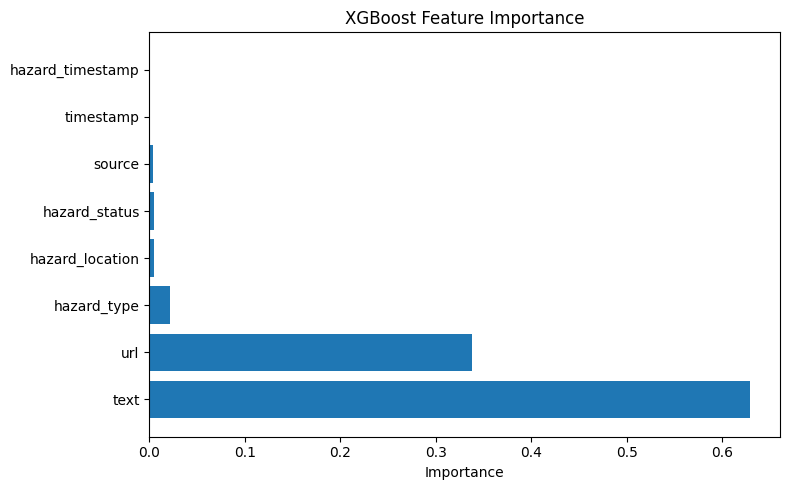

In [12]:
import matplotlib.pyplot as plt

feature_schema = {
    "features": ALL_FEATURES,
    "categorical_features": CATEGORICAL_COLS,
    "datetime_features": DATETIME_COLS,
    "text_features": TEXT_FEATURES
}

importance_full_df = pd.DataFrame({
    'feature': full_feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

agg_rows = []
for col in ALL_FEATURES:
    idxs = feature_col_map[col]
    agg_rows.append({
        'feature': col,
        'importance': float(model.feature_importances_[idxs].sum())
    })
importance_df = pd.DataFrame(agg_rows).sort_values('importance', ascending=False)

print(importance_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'])
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig(REPORT_DIR / f'feature_importance_{RUN_ID}.png', dpi=150)
plt.show()

## 11. Save Artefacts & Report

In [ ]:
# ── Save model ────────────────────────────────────────────────────────────
prefix      = config['output']['checkpoint_prefix']
model_path  = CHECKPOINT_DIR / f'{prefix}_{RUN_ID}.joblib'
joblib.dump({'model': model, 'label_encoders': label_encoders, 'target_le': target_le, 'feature_schema': feature_schema}, model_path)
print(f'Model saved: {model_path}')

# ── Save metrics report ───────────────────────────────────────────────────
report = {
    'run_id':      RUN_ID,
    'config':      config,
    'features':    ALL_FEATURES,
    'metrics':     results_df.to_dict(orient='records'),
    'robustness':  robustness_df.to_dict(orient='records'),
    'importance':  importance_df.to_dict(orient='records'),
}

report_path = REPORT_DIR / f'optimised_core_xgb_report_{RUN_ID}.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

# Also save a flat CSV for easy comparison across runs
results_df['run_id'] = RUN_ID
csv_path = REPORT_DIR / 'all_runs_metrics.csv'
header = not csv_path.exists()
results_df.to_csv(csv_path, mode='a', index=False, header=header)

print(f'Report saved: {report_path}')
print(f'Metrics appended to: {csv_path}')

## 12. Print Output Paths

In [ ]:
print("Report saved to:", report_path.resolve())
print("Model saved to:", model_path.resolve())
print("CSV saved to:", csv_path.resolve())
print("Report dir exists:", REPORT_DIR.exists())